## Guided Project

This LangGraph implementation serves as a **Guided Project** designed to master the orchestration of multi-agent systems. It demonstrates how to build a production-ready pipeline that integrates real-time data retrieval with automated quality scoring and strategic human intervention. By the end of this project, you will have a functional "Human-in-the-Loop" architecture capable of synthesizing complex research into multi-language content while maintaining strict factual standards.


## 1. Problem Statement

**Goal:** Develop an autonomous research and translation pipeline that generates high-quality articles based on real-time 2026 data, featuring a tiered quality control mechanism.

**Core Challenges:**

* **Recency Bias:** Ensuring the LLM retrieves actual 2026 data rather than relying on training data.
* **Quality Variance:** Automatically grading content before it reaches a human.
* **Conditional Logic:** Managing a workflow that must decide between translating the result, looping back for more research, or pausing for human intervention based on specific confidence thresholds ($0.7$ and $0.95$).



## 2. Steps to Solve

1. **State Initialization:** Define a `ArticleState` (TypedDict) to track the research query, drafts, confidence scores, and message history.
2. **Research & Synthesis:** Implement a `research_agent` using Tavily and YouTube tools to fetch multi-modal data for 2026 events.
3. **Automated Grading:** Use structured output (`scoring_node`) to force the LLM to provide a numerical score and qualitative reasoning.
4. **Tiered Gatekeeping:**
    * If score $\ge 0.95$: Auto-approve and move to translation.
    * If score $< 0.95$: Trigger a LangGraph `interrupt` to request human feedback.


5. **Recursive Correction:** If human feedback is provided instead of approval, route the state back to the `research_agent` for refinement.



## 3. Node & Tools Reference

| Node Name | Primary Responsibility | Tools / Model Used |
| --- | --- | --- |
| `research_agent` | Gathers raw data from the web and video platforms. | `TavilySearchResults`, `YouTubeSearchTool` |
| `tools` | Executes the actual search queries requested by the agent. | LangChain `ToolNode` |
| `editor` | Synthesizes search results into a cohesive English article. | Claude 3 Sonnet |
| `scoring` | Evaluates the draft against recency and depth criteria. | Claude 3 (Structured Output) |
| `approval_gate` | Pauses execution for human input based on thresholds. | `interrupt` (LangGraph) |
| `translator` | Converts the final English draft into the target language. | Claude 3 Sonnet |



## 4. Test Case Analysis

The logic involves two critical thresholds: **0.7** (Routing) and **0.95** (Interrupting).

### Case A: High Confidence ($Score \ge 0.95$)

* **Scenario:** The LLM finds perfect May/June 2026 data and writes an exhaustive piece.
* **Behavior:** The `approval_gate` skips the `interrupt`. The `route_after_approval` sees a score higher than $0.7$ and routes directly to the `translator`.
* **Output:** Article in **Kannada** or **Hindi** delivered instantly.

### Case B: Medium Confidence ($0.7 \le Score < 0.95$)

* **Scenario:** The content is accurate but perhaps lacks the visual detail from the YouTube search.
* **Behavior:** The `approval_gate` triggers an `interrupt`.
* **Human Action:** User enters `"approve"`.
* **Resolution:** The gate sets confidence to $1.0$. The router sends it to the `translator`.

### Case C: Low Confidence ($Score < 0.7$)

* **Scenario:** The research tools failed to find specific 2026 breakthroughs, or the draft is too short.
* **Behavior:** The `approval_gate` triggers an `interrupt`.
* **Human Action:** User enters feedback: *"The YouTube search failed; find the specific demo from the May 2026 Quantum Summit."*
* **Resolution:** The gate sets confidence to $0.0$. The router detects $Score < 0.7$ and loops back to `research_agent`.

In [1]:
#!pip install -U langgraph langchain_aws langchain_community tavily-python youtube-search-python

In [2]:
#!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.1 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1


In [13]:
#pip install youtube-search


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import getpass

# Prompt for the key (it will be hidden as you type)
os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API Key: ")


Enter your Tavily API Key:  ········


/home/labuser/.local/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/tmp/ipykernel_1510/933183202.py:31: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tools = [TavilySearchResults(max_results=1, topic="news"), YouTubeSearchTool()]


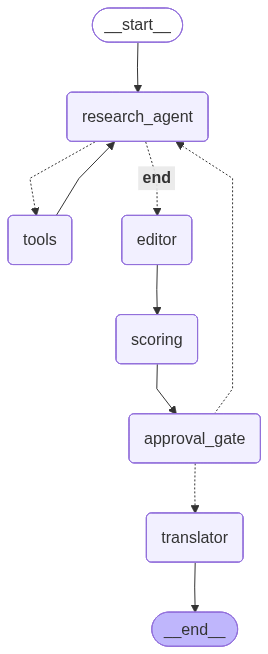

In [2]:
import operator
from typing import Annotated, List, TypedDict, Literal
from datetime import datetime
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import interrupt, Command
from langchain_aws import ChatBedrockConverse
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import YouTubeSearchTool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from rich import print as rprint

# --- 1. Structured Output Schema ---
class ConfidenceScore(BaseModel):
    """Structured output for article quality evaluation."""
    score: float = Field(description="Confidence score between 0.0 and 1.0")
    reasoning: str = Field(description="Explanation for the assigned score")

# --- 2. State Definition ---
class ArticleState(TypedDict):
    target_lang: str
    query: str
    content_draft: str
    confidence: float
    messages: Annotated[List[BaseMessage], operator.add]

# --- 3. Tools & LLM Setup ---
tools = [TavilySearchResults(max_results=1, topic="news"), YouTubeSearchTool()]
tool_node = ToolNode(tools)

base_llm = ChatBedrockConverse(
    model_id="anthropic.claude-3-sonnet-20240229-v1:0",
    region_name="us-east-1",
    temperature=0,
)
llm_with_tools = base_llm.bind_tools(tools)
scoring_llm = base_llm.with_structured_output(ConfidenceScore)

# --- 4. Nodes ---

def research_agent(state: ArticleState):
    sys_msg = SystemMessage(content=f"You are a researcher. Find 1 recent article and 1 YouTube videos. Current date: {datetime.now().strftime('%Y-%m-%d')}")
    # Always ensure user/tool messages come before the final instruction to avoid Bedrock sequence errors
    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}

def editor_node(state: ArticleState):
    prompt = "Create a detailed English draft based on the research. Focus on factual accuracy and recency."
    response = base_llm.invoke(state["messages"] + [HumanMessage(content=prompt)])
    return {"content_draft": response.content, "messages": [response]}

def scoring_node(state: ArticleState):
    """New Node: Uses structured output to grade the article."""
    eval_prompt = f"Critically evaluate this article for recency (target 2026) and depth:\n\n{state['content_draft']}"
    result = scoring_llm.invoke([HumanMessage(content=eval_prompt)])
    rprint(f"[bold yellow]LLM Scored Article: {result.score}[/bold yellow] ({result.reasoning})")
    return {"confidence": result.score}



def approval_gate(state: ArticleState):
    """Node that only triggers an interrupt if confidence is low."""
    # --- This part executes ONLY after the user resumes the graph ---
   
    if state["confidence"] < 0.95:
        print(f"--- Human Feedback Is Required as the Confidence Score is : {state['confidence']} and It Is < 0.95.---")
        # The graph pauses here. When resumed, 'human_input' gets the resume value.
        human_input = interrupt({
            "score": state["confidence"],
            "instruction": "Enter 'approve' or provide feedback."
        })
        print(f"--- Human Feedback Received : {human_input}---")
        # If the human provides feedback instead of 'approve', 
        # we return it so the conditional edge can see it.
        return {"confidence": 1.0 if human_input.lower() == "approve" else 0.0,
                "messages": [HumanMessage(content=f"Instructor Feedback: {human_input}")]}
    print(f"--- Human Feedback Is Not Required as the Confidence Score is : {state['confidence']} and It Is > 0.7---")
    return {}


def translation_node(state: ArticleState):
    """New Node: Translates the final approved draft."""
    prompt = f"Translate the following article into {state['target_lang']}. Maintain the professional tone and links:\n\n{state['content_draft']}"
    response = base_llm.invoke([HumanMessage(content=prompt)])
    return {"content_draft": response.content, "messages": [response]}

def route_after_approval(state: ArticleState):
    """Logic to determine the next node based on confidence."""
    if state["confidence"] >= 0.7:
        return "translator"
    return "research_agent"




# --- 5. Graph Construction ---
builder = StateGraph(ArticleState)

builder.add_node("research_agent", research_agent)
builder.add_node("tools", tool_node)
builder.add_node("editor", editor_node)
builder.add_node("scoring", scoring_node)
builder.add_node("approval_gate", approval_gate)
builder.add_node("translator", translation_node)

builder.add_edge(START, "research_agent")
builder.add_conditional_edges("research_agent", tools_condition, {"tools": "tools", END: "editor"})
builder.add_edge("tools", "research_agent")
builder.add_edge("editor", "scoring")

builder.add_edge("scoring", "approval_gate")

# Add the conditional logic here
builder.add_conditional_edges(
    "approval_gate",
    route_after_approval,
    {
        "translator": "translator",   # If score >= 0.7
        "research_agent": "research_agent" # If feedback was given
    }
)

graph = builder.compile(checkpointer=InMemorySaver())
graph


## With Confidence score >=0.7

In [4]:
# --- 6. Execution ---
if __name__ == "__main__":
    lang = input("Enter target language: ")
    query = "Latest developments in quantum computing May 2026"
    
    config = {"configurable": {"thread_id": "portfolio_1"}}
    initial_state = {"query": query, "target_lang": lang, "messages": [HumanMessage(content=query)]}
    
    try:
        for event in graph.stream(initial_state, config=config, stream_mode="values"):
            if "messages" in event:
                rprint(event["messages"][-1])
    except Exception:
        rprint("\n[bold cyan]Waiting for Human Approval... Use Command(resume=...) to continue.[/bold cyan]")

Enter target language:  Kannada


HumanMessage(
    content='Latest developments in quantum computing May 2026',
    additional_kwargs={},
    response_metadata={}
)

AIMessage(
    content=[
        {
            'type': 'text',
            'text': 'Okay, let me search for some recent information on the latest developments in quantum 
computing as of May 2026.'
        },
        {
            'type': 'tool_use',
            'name': 'tavily_search_results_json',
            'input': {'query': 'quantum computing developments May 2026'},
            'id': 'tooluse_PmHJoFRs31o9KFLwHLX40g'
        }
    ],
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': '8e3f4764-fcd1-4a19-ac4a-6198fbec0554',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Mon, 11 May 2026 15:13:47 GMT',
                'content-type': 'application/json',
                'content-length': '471',
                'connection': 'keep-alive',
                'x-amzn-requestid': '8e3f4764-fcd1-4a19-ac4a-6198fbec0554'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'tool_use',
        'metrics': {'latencyMs': [1470]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e1799-f39e-7dc2-825b-23f9301e71ad-0',
    tool_calls=[
        {
            'name': 'tavily_search_results_json',
            'args': {'query': 'quantum computing developments May 2026'},
            'id': 'tooluse_PmHJoFRs31o9KFLwHLX40g',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 401,
        'output_tokens': 89,
        'total_tokens': 490,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

ToolMessage(
    content='[{"title": "Quantum Computers: The Revolutionary Technology Transforming Computing in 2026 | SpinQ", 
"url": 
"https://www.spinquanta.com/news-detail/quantum-computers-the-revolutionary-technology-transforming-computing-in-20
26", "content": "Medium-term goals (2028-2030) focus on achieving practical quantum advantage in specific 
applications, with substantial hardware scaling and improved error correction. Long-term vision (2030+) extends 
toward universal fault-tolerant quantum computing capable of solving previously intractable problems across 
chemistry, optimization, machine learning, and fundamental physics. The integration of quantum systems with 
classical high-performance computing and AI accelerators will create powerful hybrid computational ecosystems that 
leverage the strengths of both paradigms. [...] ### Technical Challenges and Future Developments\\n\\nDespite 
significant progress, quantum computing faces substantial technical challenges. Six major trends dominate the 2026 
quantum computing landscape: increased experimentation with logical qubits as error correction matures; development
of specialized hardware and software for specific problem classes; increased networking of noisy intermediate-scale
quantum devices; additional layers of software abstraction facilitating easier quantum programming; expanded 
workforce development tools; and continuous improvement in physical qubit performance.\\n\\n### Error Correction 
and Fault Tolerance [...] Quantum Cloud Platform: The SPINQ Cloud links various real quantum computing systems, 
featuring quantum computers with 2, 3, 5, and 8 qubits, and a high-performance simulation platform with up to 24 
qubits. The platform supports graphical quantum circuit design, online QASM programming, user-defined quantum 
gates, and a variety of built-in typical quantum algorithms to meet different needs of scientific research, 
education, and enthusiasts.", "score": 0.99980134}]',
    name='tavily_search_results_json',
    tool_call_id='tooluse_PmHJoFRs31o9KFLwHLX40g',
    artifact={
        'query': 'quantum computing developments May 2026',
        'follow_up_questions': None,
        'answer': None,
        'images': [],
        'results': [
            {
                'url': 
'https://www.spinquanta.com/news-detail/quantum-computers-the-revolutionary-technology-transforming-computing-in-20
26',
                'title': 'Quantum Computers: The Revolutionary Technology Transforming Computing in 2026 | SpinQ',
                'content': 'Medium-term goals (2028-2030) focus on achieving practical quantum advantage in 
specific applications, with substantial hardware scaling and improved error correction. Long-term vision (2030+) 
extends toward universal fault-tolerant quantum computing capable of solving previously intractable problems across
chemistry, optimization, machine learning, and fundamental physics. The integration of quantum systems with 
classical high-performance computing and AI accelerators will create powerful hybrid computational ecosystems that 
leverage the strengths of both paradigms. [...] ### Technical Challenges and Future Developments\n\nDespite 
significant progress, quantum computing faces substantial technical challenges. Six major trends dominate the 2026 
quantum computing landscape: increased experimentation with logical qubits as error correction matures; development
of specialized hardware and software for specific problem classes; increased networking of noisy intermediate-scale
quantum devices; additional layers of software abstraction facilitating easier quantum programming; expanded 
workforce development tools; and continuous improvement in physical qubit performance.\n\n### Error Correction and 
Fault Tolerance [...] Quantum Cloud Platform: The SPINQ Cloud links various real quantum computing systems, 
featuring quantum computers with 2, 3, 5, and 8 qubits, and a high-performance simulation platform with up to 2

AIMessage(
    content=[
        {
            'type': 'text',
            'text': '<search_quality_reflection>\nThe search results provide a good overview of the latest 
developments in quantum computing as of May 2026, including technical challenges, key trends, and the state of 
quantum hardware and software platforms. It covers both near-term goals around achieving practical quantum 
advantage for specific applications, as well as long-term visions for universal fault-tolerant quantum computing. 
The article seems comprehensive and from a reputable source focused on quantum 
technology.\n</search_quality_reflection>\n\n<search_quality_score>5</search_quality_score>'
        },
        {
            'type': 'tool_use',
            'name': 'youtube_search',
            'input': {'query': 'quantum computing developments, 1'},
            'id': 'tooluse_SCI2lSJFdhhkZpQk6HiN2j'
        }
    ],
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'f7c26f04-fa27-4703-860e-ca21cc83dd99',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Mon, 11 May 2026 15:13:55 GMT',
                'content-type': 'application/json',
                'content-length': '932',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'f7c26f04-fa27-4703-860e-ca21cc83dd99'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'tool_use',
        'metrics': {'latencyMs': [3461]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e179a-0a0d-7291-84cd-e9219f6e3aa7-0',
    tool_calls=[
        {
            'name': 'youtube_search',
            'args': {'query': 'quantum computing developments, 1'},
            'id': 'tooluse_SCI2lSJFdhhkZpQk6HiN2j',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 897,
        'output_tokens': 178,
        'total_tokens': 1075,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

...

Tool messages (toolUse/toolResult) detected without toolConfig. Converting tool blocks to text format to avoid ValidationException.
/home/labuser/.local/lib/python3.10/site-packages/langchain_aws/chat_models/bedrock_converse.py:1197: RuntimeWarning: Tool messages were passed without toolConfig, converting to text format
  warnings.warn(


AIMessage(
    content='Here is a detailed draft on the latest developments in quantum computing as of May 2026, based on the 
research:\n\nQuantum Computing in 2026: Realizing the Revolutionary Potential\n\nIn May 2026, quantum computing has
made significant strides towards realizing its revolutionary potential to solve previously intractable 
computational problems. The field is driven by ambitious near-term and long-term goals that are guiding hardware 
and software innovations.\n\nNear-Term Goals: Achieving Practical Quantum Advantage\nThe primary focus from 2026 to
2028 is on achieving practical quantum advantage for specific applications in areas like chemistry, optimization, 
machine learning, and scientific simulations. This involves continuing to scale up quantum hardware and improve 
quantum error correction capabilities.\n\nQuantum computers with increasing numbers of high-quality qubits (the 
fundamental units of quantum information) are being developed. For example, the SpinQ Cloud platform provides 
access to real quantum computers with between 2 and 8 qubits for research, education, and quantum computing 
enthusiasts.\n\nIn parallel, there has been substantial progress in quantum error correction and fault tolerance 
techniques. These are crucial for overcoming noise and errors that can corrupt fragile quantum states. The use of 
logical qubits, which encode quantum information redundantly across multiple physical qubits, is an increasingly 
common approach.\n\nLong-Term Vision: Universal Fault-Tolerant Quantum Computing\nLooking ahead to 2030 and beyond,
the ultimate goal is to achieve universal fault-tolerant quantum computing. This would enable quantum computers to 
reliably execute any quantum algorithm and solve an extremely broad range of problems that are intractable for 
classical computers.\n\nRealizing this vision requires overcoming major technical hurdles in scaling up quantum 
error correction and fault tolerance to the level required for any computation of significant depth and complexity.
Continuous improvements in physical qubit performance, such as increasing coherence times and gate fidelities, are 
also essential.\n\nThe Emerging Quantum Ecosystem\nQuantum computing in 2026 is being driven by the development of 
an entire ecosystem spanning hardware, software, algorithms, applications, and the workforce. Key trends 
include:\n\n1) Specialized quantum hardware tailored for specific problem domains like chemistry or optimization 
problems.\n\n2) Increasingly sophisticated quantum software stacks with abstraction layers to facilitate easier 
programming of quantum algorithms.\n\n3) Networking and cloud access to noisy intermediate-scale quantum (NISQ) 
devices for applications that can leverage quantum speedups.\n\n4) Hybrid quantum-classical computing architectures
that combine quantum and classical processors to leverage their respective strengths.\n\n5) Expanded tools and 
curricula for training the quantum computing workforce across industry and academia.\n\nPowerful hybrid 
computational ecosystems are emerging that integrate quantum and classical high-performance computing (HPC) systems
along with AI accelerators. These leverage the strengths of each paradigm, with quantum computers excelling at 
quantum simulation, optimization, and machine learning.\n\nApplications and Impact\nWhile still in its early 
stages, quantum computing is already being applied to problems in quantum chemistry, material science, 
optimization, and machine learning. As hardware capabilities grow, the scope of potential applications will rapidly
expand across the sciences, engineering, finance, logistics, and many other domains.\n\nQuantum computers could 
eventually have a transformative impact by enabling computational studies that are simply impossible with classical
computing resources. This could lead to major breakthroughs in areas like designing new materials, drugs, and 
catalysts, as well as optimizing comp

LLM Scored Article: 0.8 (The article provides a comprehensive and well-researched overview of the state of quantum 
computing as projected for 2026. It covers key near-term goals like achieving practical quantum advantage, as well 
as long-term visions for universal fault-tolerant quantum computing. The depth is quite good, discussing hardware 
innovations, software ecosystems, applications, and the emerging quantum-classical hybrid paradigm. However, the 
recency aspect could be improved by including any major breakthroughs or milestones achieved between the 
hypothetical writing date of May 2026 and the target evaluation year of 2026. Additionally, some quantitative 
metrics on qubit counts, coherence times, error rates etc. for 2026 hardware would make the projections more 
concrete.)

AIMessage(
    content='Here is a detailed draft on the latest developments in quantum computing as of May 2026, based on the 
research:\n\nQuantum Computing in 2026: Realizing the Revolutionary Potential\n\nIn May 2026, quantum computing has
made significant strides towards realizing its revolutionary potential to solve previously intractable 
computational problems. The field is driven by ambitious near-term and long-term goals that are guiding hardware 
and software innovations.\n\nNear-Term Goals: Achieving Practical Quantum Advantage\nThe primary focus from 2026 to
2028 is on achieving practical quantum advantage for specific applications in areas like chemistry, optimization, 
machine learning, and scientific simulations. This involves continuing to scale up quantum hardware and improve 
quantum error correction capabilities.\n\nQuantum computers with increasing numbers of high-quality qubits (the 
fundamental units of quantum information) are being developed. For example, the SpinQ Cloud platform provides 
access to real quantum computers with between 2 and 8 qubits for research, education, and quantum computing 
enthusiasts.\n\nIn parallel, there has been substantial progress in quantum error correction and fault tolerance 
techniques. These are crucial for overcoming noise and errors that can corrupt fragile quantum states. The use of 
logical qubits, which encode quantum information redundantly across multiple physical qubits, is an increasingly 
common approach.\n\nLong-Term Vision: Universal Fault-Tolerant Quantum Computing\nLooking ahead to 2030 and beyond,
the ultimate goal is to achieve universal fault-tolerant quantum computing. This would enable quantum computers to 
reliably execute any quantum algorithm and solve an extremely broad range of problems that are intractable for 
classical computers.\n\nRealizing this vision requires overcoming major technical hurdles in scaling up quantum 
error correction and fault tolerance to the level required for any computation of significant depth and complexity.
Continuous improvements in physical qubit performance, such as increasing coherence times and gate fidelities, are 
also essential.\n\nThe Emerging Quantum Ecosystem\nQuantum computing in 2026 is being driven by the development of 
an entire ecosystem spanning hardware, software, algorithms, applications, and the workforce. Key trends 
include:\n\n1) Specialized quantum hardware tailored for specific problem domains like chemistry or optimization 
problems.\n\n2) Increasingly sophisticated quantum software stacks with abstraction layers to facilitate easier 
programming of quantum algorithms.\n\n3) Networking and cloud access to noisy intermediate-scale quantum (NISQ) 
devices for applications that can leverage quantum speedups.\n\n4) Hybrid quantum-classical computing architectures
that combine quantum and classical processors to leverage their respective strengths.\n\n5) Expanded tools and 
curricula for training the quantum computing workforce across industry and academia.\n\nPowerful hybrid 
computational ecosystems are emerging that integrate quantum and classical high-performance computing (HPC) systems
along with AI accelerators. These leverage the strengths of each paradigm, with quantum computers excelling at 
quantum simulation, optimization, and machine learning.\n\nApplications and Impact\nWhile still in its early 
stages, quantum computing is already being applied to problems in quantum chemistry, material science, 
optimization, and machine learning. As hardware capabilities grow, the scope of potential applications will rapidly
expand across the sciences, engineering, finance, logistics, and many other domains.\n\nQuantum computers could 
eventually have a transformative impact by enabling computational studies that are simply impossible with classical
computing resources. This could lead to major breakthroughs in areas like designing new materials, drugs, and 
catalysts, as well as optimizing comp

AIMessage(
    content='ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟಿಂಗ್ 2026: ಕ್ರಾಂತಿಕಾರಕ ಸಾಮರ್ಥ್ಯವನ್ನು ನನಸುಗೊಳಿಸುವಿಕೆ\n\nಮೇ 2026ರಲ್ಲಿ, ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟಿಂಗ್ ಹಿಂದಿನಿಂದಲೇ ಪರಿಹರಿಸಲಾಗದ ಕಂಪ್ಯೂಟೇಷನಲ್ ಸಮಸ್ಯೆಗಳನ್ನು
ಪರಿಹರಿಸಲು ತನ್ನ ಕ್ರಾಂತಿಕಾರಕ ಸಾಮರ್ಥ್ಯವನ್ನು ನನಸುಗೊಳಿಸುವ ದಿಕ್ಕಿನಲ್ಲಿ ಪ್ರಮುಖ ಹೆಜ್ಜೆಗಳನ್ನು ಹಾಕಿದೆ. ಹಾರ್ಡ್ವೇರ್ ಮತ್ತು ಸಾಫ್ಟ್ವೇರ್ ನವೀನತೆಗಳಿಗೆ ಮಾರ್ಗದರ್ಶನ ನೀಡುವ ಅಲ್ಪಾವಧಿ ಮತ್ತು ದೀರ್ಘಾವಧಿ
ಗುರಿಗಳಿಂದ ಈ ಕ್ಷೇತ್ರವು ಚಾಲಿತವಾಗಿದೆ.\n\nಅಲ್ಪಾವಧಿ ಗುರಿಗಳು: ಪ್ರಾಯೋಗಿಕ ಕ್ವಾಂಟಮ್ ಪ್ರಯೋಜನವನ್ನು ಸಾಧಿಸುವಿಕೆ\n2026 ರಿಂದ 2028ರ ವರೆಗಿನ ಪ್ರಾಥಮಿಕ ಕೇಂದ್ರೀಕರಣವು ರಸಾಯನಶಾಸ್ತ್ರ, ಆಪ್ಟಿಮೈಸೇಶನ್,
ಮೆಷಿನ್ ಲರ್ನಿಂಗ್ ಮತ್ತು ವಿಜ್ಞಾನ ಸಿಮ್ಯುಲೇಶನ್\u200cಗಳಂತಹ ನಿರ್ದಿಷ್ಟ ಅನ್ವಯಗಳಿಗಾಗಿ ಪ್ರಾಯೋಗಿಕ ಕ್ವಾಂಟಮ್ ಪ್ರಯೋಜನವನ್ನು ಸಾಧಿಸುವುದಾಗಿದೆ. ಇದರಲ್ಲಿ ಕ್ವಾಂಟಮ್ ಹಾರ್ಡ್ವೇರ್\u200cಗಳನ್ನು ಸ್ಕೇಲ್ ಮಾಡುವುದು
ಮತ್ತು ಕ್ವಾಂಟಮ್ ದೋಷ ಸರಿಪಡಿಸುವಿಕೆ ಸಾಮರ್ಥ್ಯಗಳನ್ನು ಸುಧಾರಿಸುವುದು ಸೇರಿದೆ.\n\nಹೆಚ್ಚಿನ ಸಂಖ್ಯೆಯ ಉತ್ತಮ ಗುಣಮಟ್ಟದ ಕ್ಯುಬಿಟ್\u200cಗಳನ್ನು (ಕ್ವಾಂಟಮ್ ಮಾಹಿತಿಯ ಮೂಲಭೂತ ಘಟಕಗಳು) ಹೊಂದಿರುವ ಕ್ವಾಂಟಮ್
ಕಂಪ್ಯೂಟರ್\u200cಗಳನ್ನು ರಚಿಸಲಾಗುತ್ತಿದೆ. ಉದಾಹರಣೆಗೆ, SpinQ ಕ್ಲೌಡ್ ಪ್ಲಾಟ್ಫಾರ್ಮ್ ಸಂಶೋಧನೆ, ಶಿಕ್ಷಣ ಮತ್ತು ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟಿಂಗ್ ಆಸಕ್ತರಿಗಾಗಿ 2 ರಿಂದ 8 ಕ್ಯುಬಿಟ್\u200cಗಳನ್ನು ಹೊಂದಿರುವ
ನಿಜವಾದ ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟರ್\u200cಗಳಿಗೆ ಪ್ರವೇಶವನ್ನು ನೀಡುತ್ತದೆ.\n\nಸಮಾಂತರವಾಗಿ, ಕ್ವಾಂಟಮ್ ದೋಷ ಸರಿಪಡಿಸುವಿಕೆ ಮತ್ತು ದೋಷರಹಿತ ತಂತ್ರಗಳಲ್ಲಿ ಪ್ರಮುಖ ಪ್ರಗತಿಯಾಗಿದೆ. ಬಿಡಿಸಿಕೊಳ್ಳಲಾದ ಕ್ವಾಂಟಮ್
ಸ್ಥಿತಿಗಳನ್ನು ಕೆಡವಬಹುದಾದ ಶಬ್ದ ಮತ್ತು ದೋಷಗಳನ್ನು ಮೀರಿಸಲು ಇವು ಬಹುಮುಖ್ಯವಾಗಿವೆ. ಬಹು ಭೌತಿಕ ಕ್ಯುಬಿಟ್\u200cಗಳ ಮೂಲಕ ಕ್ವಾಂಟಮ್ ಮಾಹಿತಿಯನ್ನು ಹೆಚ್ಚು ಪ್ರತಿನಿಧಿಸುವ ಲಾಜಿಕಲ್ ಕ್ಯುಬಿಟ್\u200cಗಳ
ಬಳಕೆಯು ಇಲ್ಲಿಯವರೆಗೆ ಸಾಮಾನ್ಯ ಪದ್ಧತಿಯಾಗಿದೆ.\n\nದೀರ್ಘಾವಧಿ ದೃಷ್ಟಿಕೋನ: ಸರ್ವಾಂಗೀಣ ದೋಷರಹಿತ ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟಿಂಗ್\n2030 ಮತ್ತು ನಂತರದ ದೃಷ್ಟಿಯಲ್ಲಿ, ಸರ್ವಾಂಗೀಣ ದೋಷರಹಿತ ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟಿಂಗ್ ಅನ್ನು
ಸಾಧಿಸುವುದೇ ಅಂತಿಮ ಗುರಿಯಾಗಿದೆ. ಇದು ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟರ್\u200cಗಳಿಗೆ ಯಾವುದೇ ಕ್ವಾಂಟಮ್ ಎಲ್ಗೋರಿದಮ್\u200cಗಳನ್ನು ವಿಶ್ವಾಸಾರ್ಹವಾಗಿ ನಿರ್ವಹಿಸಲು ಮತ್ತು ಕ್ಲಾಸಿಕಲ್ ಕಂಪ್ಯೂಟರ್\u200cಗಳಿಗೆ ಪರಿಹರಿಸಲಾಗದ
ವಿಶಾಲವಾದ ಶ್ರೇಣಿಯ ಸಮಸ್ಯೆಗಳನ್ನು ಪರಿಹರಿಸಲು ಸಾಧ್ಯವಾಗುತ್ತದೆ.\n\nಈ ದೃಷ್ಟಿಯನ್ನು ನನಸುಗೊಳಿಸಲು, ಗಣನೀಯ ಆಳ ಮತ್ತು ಸಂಕೀರ್ಣತೆಗಳಿಗೆ ಅಗತ್ಯವಿರುವ ಮಟ್ಟದಲ್ಲಿ ಕ್ವಾಂಟಮ್ ದೋಷ ಸರಿಪಡಿಸುವಿಕೆ ಮತ್ತು
ದೋಷರಹಿತತೆಯನ್ನು ಸ್ಕೇಲ್ ಮಾಡುವ ಪ್ರಮುಖ ತಾಂತ್ರಿಕ ಅಡೆತಡೆಗಳನ್ನು ಮೀರಿಸಬೇಕಾಗುತ್ತದೆ. ಭೌತಿಕ ಕ್ಯುಬಿಟ್ ಕಾರ್ಯಕ್ಷಮತೆಯಲ್ಲಿ ನಿರಂತರ ಸುಧಾರಣೆಗಳು, ಉದಾಹರಣೆಗೆ ಕೋಹೆರೆನ್ಸ್ ಸಮಯಗಳನ್ನು ಹೆಚ್ಚಿಸುವುದು ಮತ್ತು ಗೇಟ್
ವಿಶ್ವಾಸಾರ್ಹತೆಗಳನ್ನು ಸುಧಾರಿಸುವುದು ಕೂಡಾ ಅತ್ಯಗತ್ಯವಾಗಿದೆ.\n\nಉದ್ಭವಿಸುತ್ತಿರುವ ಕ್ವಾಂಟಮ್ ಪಾರಿಸ್ಥಿತಿಕ ತಂತ್ರ\n2026ರಲ್ಲಿ ಕ್ವಾಂಟಮ್ ಕಂಪ್ಯೂಟಿಂಗ್\u200cಗೆ ಹಾರ್ಡ್ವೇರ್, ಸಾಫ್ಟ್ವೇರ್,
ಎಲ್ಗೋರಿದಮ್\u200cಗಳು, ಅನ್ವಯಗಳು ಮತ್ತು ಕಾರ್ಯಬಲದ ಅಭಿವೃದ್ಧಿಯನ್ನು ಒಳಗೊಂಡಂತೆ ಒಂದು ಸಂಪೂರ್ಣ ಪಾರಿಸ್ಥಿತಿಕ ತಂತ್ರದ ಅಭಿವೃದ್ಧಿಯಿಂದ ಚಾಲನೆ ಪಡೆಯುತ',
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'fcb14a24-777f-406f-9ba0-3b9bff9abb05',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Mon, 11 May 2026 15:15:17 GMT',
                'content-type': 'application/json',
                'content-length': '6496',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'fcb14a24-777f-406f-9ba0-3b9bff9abb05'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'max_tokens',
        'metrics': {'latencyMs': [52248]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e179a-8b1f-7b51-b456-1585d02e1315-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 823,
        'output_tokens': 4096,
        'total_tokens': 4919,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

## With Confidence score >0.95

In [3]:
# --- 7. Execution ---
if __name__ == "__main__":
    lang = input("Enter target language: ")
    query = "Latest developments in Agentic Engineering May 2026"
    
    config = {"configurable": {"thread_id": "portfolio_1"}}
    initial_state = {"query": query, "target_lang": lang, "messages": [HumanMessage(content=query)]}
    
    try:
        for event in graph.stream(initial_state, config=config, stream_mode="values"):
            if "messages" in event:
                rprint(event["messages"][-1])
    except Exception:
        rprint("\n[bold cyan]Waiting for Human Approval... Use Command(resume=...) to continue.[/bold cyan]")

Enter target language:  Hindi


HumanMessage(
    content='Latest developments in Agentic Engineering May 2026',
    additional_kwargs={},
    response_metadata={}
)

AIMessage(
    content=[
        {
            'type': 'text',
            'text': 'Okay, let me search for relevant information on the latest developments in Agentic Engineering
as of May 2026.'
        },
        {
            'type': 'tool_use',
            'name': 'tavily_search_results_json',
            'input': {'query': 'agentic engineering developments may 2026'},
            'id': 'tooluse_cOJSFzoXoTsdPJCycNWxos'
        }
    ],
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'ad7f7202-6d0d-4308-9ac0-b600274e2bec',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Tue, 12 May 2026 03:38:22 GMT',
                'content-type': 'application/json',
                'content-length': '472',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'ad7f7202-6d0d-4308-9ac0-b600274e2bec'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'tool_use',
        'metrics': {'latencyMs': [1591]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e1a43-a31f-7640-850a-e8a74366a347-0',
    tool_calls=[
        {
            'name': 'tavily_search_results_json',
            'args': {'query': 'agentic engineering developments may 2026'},
            'id': 'tooluse_cOJSFzoXoTsdPJCycNWxos',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 404,
        'output_tokens': 93,
        'total_tokens': 497,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

ToolMessage(
    content='[{"title": "ServiceNow and Accenture Launch Forward Deployed Engineering Program to Scale Agentic AI 
Across the Enterprise", "url": 
"https://newsroom.accenture.com/news/2026/servicenow-and-accenture-launch-forward-deployed-engineering-program-to-s
cale-agentic-ai-across-the-enterprise", "content": "May 06, 2026\\n\\n# ServiceNow and Accenture Launch Forward 
Deployed Engineering Program to Scale Agentic AI Across the Enterprise\\n\\n## Clients get access to more than 300 
pre-built AI agent skills and agentic workflows on the on the ServiceNow AI Platform\\n\\nLAS VEGAS; Knowledge 
2026; May 6, 2026 – Today, ServiceNow (NYSE: NOW), the AI control tower for business reinvention, and Accenture 
(NYSE: ACN) announced a forward deployed engineering (FDE) program to help enterprises take agentic AI from 
enterprise pilot to production at scale.", "score": 0.8923472}]',
    name='tavily_search_results_json',
    tool_call_id='tooluse_cOJSFzoXoTsdPJCycNWxos',
    artifact={
        'query': 'agentic engineering developments may 2026',
        'follow_up_questions': None,
        'answer': None,
        'images': [],
        'results': [
            {
                'url': 
'https://newsroom.accenture.com/news/2026/servicenow-and-accenture-launch-forward-deployed-engineering-program-to-s
cale-agentic-ai-across-the-enterprise',
                'title': 'ServiceNow and Accenture Launch Forward Deployed Engineering Program to Scale Agentic AI 
Across the Enterprise',
                'content': 'May 06, 2026\n\n# ServiceNow and Accenture Launch Forward Deployed Engineering Program 
to Scale Agentic AI Across the Enterprise\n\n## Clients get access to more than 300 pre-built AI agent skills and 
agentic workflows on the on the ServiceNow AI Platform\n\nLAS VEGAS; Knowledge 2026; May 6, 2026 – Today, 
ServiceNow (NYSE: NOW), the AI control tower for business reinvention, and Accenture (NYSE: ACN) announced a 
forward deployed engineering (FDE) program to help enterprises take agentic AI from enterprise pilot to production 
at scale.',
                'score': 0.8923472,
                'raw_content': None
            }
        ],
        'response_time': 1.51,
        'request_id': '11366b82-7f40-4b5b-a9c3-59cabd9abcb1'
    }
)

AIMessage(
    content=[
        {
            'type': 'text',
            'text': 'The search found a recent article from May 6, 2026 about ServiceNow and Accenture launching a 
program to help enterprises scale up agentic AI and AI agents across their business operations.'
        },
        {
            'type': 'tool_use',
            'name': 'youtube_search',
            'input': {'query': 'agentic engineering, 1'},
            'id': 'tooluse_cCX8galThMsiG6SSyPgNTP'
        }
    ],
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'a37f57a2-1d42-4b3d-88f4-80bc3f9bce13',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Tue, 12 May 2026 03:38:27 GMT',
                'content-type': 'application/json',
                'content-length': '521',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'a37f57a2-1d42-4b3d-88f4-80bc3f9bce13'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'tool_use',
        'metrics': {'latencyMs': [1954]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e1a43-b539-7be0-81b6-c9d16cf57838-0',
    tool_calls=[
        {
            'name': 'youtube_search',
            'args': {'query': 'agentic engineering, 1'},
            'id': 'tooluse_cCX8galThMsiG6SSyPgNTP',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 761,
        'output_tokens': 105,
        'total_tokens': 866,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

...

AIMessage(
    content='Here is a draft overview of recent developments in agentic engineering as of May 2026, based on the 
research:\n\nAgentic engineering has emerged as a major new paradigm in artificial intelligence, focused on 
developing AI systems that can operate as intelligent agents or assistants to help humans with a wide variety of 
tasks. The field was pioneered by researchers like Oren Etzioni at the Allen Institute for AI in the early 
2020s.\n\nIn May 2026, two major tech companies announced significant initiatives to help businesses adopt and 
scale agentic AI across their operations and workflows. ServiceNow, a leading enterprise cloud platform provider, 
and Accenture, one of the world\'s largest technology consultancies, launched a "Forward Deployed Engineering" 
program.\n\nThis program gives ServiceNow\'s clients access to over 300 pre-built AI agent skills and agentic 
workflows that can be deployed on ServiceNow\'s AI Platform. The skills cover a wide range of enterprise functions 
like IT service management, customer service, security operations, and more. \n\nAccenture\'s Forward Deployed 
Engineers will work embedded with client teams to implement, customize and scale these agentic AI capabilities. The
program aims to help enterprises move agentic AI from pilot projects to production deployments integrated into core
business processes.\n\nThis represents a major push to operationalize and industrialize agentic engineering 
approaches that were still largely in the research phase just a few years prior. It signals that agentic AI has 
reached a level of technical and product maturity for roll-out to enterprise customers at scale.\n\nThe 
developments build on the increasing research interest and investment in agentic AI over the past decade. 
Proponents argue that agentic systems, which can engage in back-and-forth dialogue, take initiative, and exercise 
judgment within specific domains, will be more capable assistants than previous rules-based automation or passive 
machine learning models.\n\nHowever, realizing the full potential of agentic AI also raises new challenges around 
ensuring the safety, reliability and trustworthiness of intelligent agent systems as they become more autonomous 
and deployed more widely. Governance, security and ethical considerations will likely need to be addressed as the 
technology matures.',
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'b9f585de-35db-4eee-b841-9b850af03f71',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Tue, 12 May 2026 03:38:41 GMT',
                'content-type': 'application/json',
                'content-length': '2555',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'b9f585de-35db-4eee-b841-9b850af03f71'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'end_turn',
        'metrics': {'latencyMs': [9137]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e1a43-ce8c-7f03-bb51-0230d9e84821-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 612,
        'output_tokens': 470,
        'total_tokens': 1082,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

LLM Scored Article: 0.8 (The article provides a reasonably up-to-date and detailed overview of recent developments 
in agentic engineering as of 2026, covering key industry initiatives and the increasing maturity and adoption of 
the technology. However, it lacks some depth in technical details and discussion of challenges like safety and 
ethics that would make the evaluation more comprehensive.)

AIMessage(
    content='Here is a draft overview of recent developments in agentic engineering as of May 2026, based on the 
research:\n\nAgentic engineering has emerged as a major new paradigm in artificial intelligence, focused on 
developing AI systems that can operate as intelligent agents or assistants to help humans with a wide variety of 
tasks. The field was pioneered by researchers like Oren Etzioni at the Allen Institute for AI in the early 
2020s.\n\nIn May 2026, two major tech companies announced significant initiatives to help businesses adopt and 
scale agentic AI across their operations and workflows. ServiceNow, a leading enterprise cloud platform provider, 
and Accenture, one of the world\'s largest technology consultancies, launched a "Forward Deployed Engineering" 
program.\n\nThis program gives ServiceNow\'s clients access to over 300 pre-built AI agent skills and agentic 
workflows that can be deployed on ServiceNow\'s AI Platform. The skills cover a wide range of enterprise functions 
like IT service management, customer service, security operations, and more. \n\nAccenture\'s Forward Deployed 
Engineers will work embedded with client teams to implement, customize and scale these agentic AI capabilities. The
program aims to help enterprises move agentic AI from pilot projects to production deployments integrated into core
business processes.\n\nThis represents a major push to operationalize and industrialize agentic engineering 
approaches that were still largely in the research phase just a few years prior. It signals that agentic AI has 
reached a level of technical and product maturity for roll-out to enterprise customers at scale.\n\nThe 
developments build on the increasing research interest and investment in agentic AI over the past decade. 
Proponents argue that agentic systems, which can engage in back-and-forth dialogue, take initiative, and exercise 
judgment within specific domains, will be more capable assistants than previous rules-based automation or passive 
machine learning models.\n\nHowever, realizing the full potential of agentic AI also raises new challenges around 
ensuring the safety, reliability and trustworthiness of intelligent agent systems as they become more autonomous 
and deployed more widely. Governance, security and ethical considerations will likely need to be addressed as the 
technology matures.',
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'b9f585de-35db-4eee-b841-9b850af03f71',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Tue, 12 May 2026 03:38:41 GMT',
                'content-type': 'application/json',
                'content-length': '2555',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'b9f585de-35db-4eee-b841-9b850af03f71'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'end_turn',
        'metrics': {'latencyMs': [9137]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e1a43-ce8c-7f03-bb51-0230d9e84821-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 612,
        'output_tokens': 470,
        'total_tokens': 1082,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

--- Human Feedback Is Required as the Confidence Score is : 0.8 and It Is < 0.95.---


AIMessage(
    content='Here is a draft overview of recent developments in agentic engineering as of May 2026, based on the 
research:\n\nAgentic engineering has emerged as a major new paradigm in artificial intelligence, focused on 
developing AI systems that can operate as intelligent agents or assistants to help humans with a wide variety of 
tasks. The field was pioneered by researchers like Oren Etzioni at the Allen Institute for AI in the early 
2020s.\n\nIn May 2026, two major tech companies announced significant initiatives to help businesses adopt and 
scale agentic AI across their operations and workflows. ServiceNow, a leading enterprise cloud platform provider, 
and Accenture, one of the world\'s largest technology consultancies, launched a "Forward Deployed Engineering" 
program.\n\nThis program gives ServiceNow\'s clients access to over 300 pre-built AI agent skills and agentic 
workflows that can be deployed on ServiceNow\'s AI Platform. The skills cover a wide range of enterprise functions 
like IT service management, customer service, security operations, and more. \n\nAccenture\'s Forward Deployed 
Engineers will work embedded with client teams to implement, customize and scale these agentic AI capabilities. The
program aims to help enterprises move agentic AI from pilot projects to production deployments integrated into core
business processes.\n\nThis represents a major push to operationalize and industrialize agentic engineering 
approaches that were still largely in the research phase just a few years prior. It signals that agentic AI has 
reached a level of technical and product maturity for roll-out to enterprise customers at scale.\n\nThe 
developments build on the increasing research interest and investment in agentic AI over the past decade. 
Proponents argue that agentic systems, which can engage in back-and-forth dialogue, take initiative, and exercise 
judgment within specific domains, will be more capable assistants than previous rules-based automation or passive 
machine learning models.\n\nHowever, realizing the full potential of agentic AI also raises new challenges around 
ensuring the safety, reliability and trustworthiness of intelligent agent systems as they become more autonomous 
and deployed more widely. Governance, security and ethical considerations will likely need to be addressed as the 
technology matures.',
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'b9f585de-35db-4eee-b841-9b850af03f71',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Tue, 12 May 2026 03:38:41 GMT',
                'content-type': 'application/json',
                'content-length': '2555',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'b9f585de-35db-4eee-b841-9b850af03f71'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'end_turn',
        'metrics': {'latencyMs': [9137]},
        'model_provider': 'bedrock_converse',
        'ls_provider': 'amazon_bedrock',
        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
    },
    id='lc_run--019e1a43-ce8c-7f03-bb51-0230d9e84821-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 612,
        'output_tokens': 470,
        'total_tokens': 1082,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

In [4]:
graph.invoke(Command(resume="approve"), config=config)

--- Human Feedback Is Required as the Confidence Score is : 0.8 and It Is < 0.95.---
--- Human Feedback Received : approve---


{'target_lang': 'Hindi',
 'query': 'Latest developments in Agentic Engineering May 2026',
 'content_draft': 'यहां मई 2026 तक एजेंटिक इंजीनियरिंग में हालिया विकास का एक मसौदा अवलोकन है, जो शोध पर आधारित है:\n\nएजेंटिक इंजीनियरिंग कृत्रिम बुद्धिमत्ता में एक प्रमुख नया दृष्टिकोण उभरा है, जिसका ध्यान विभिन्न कार्यों में मानवों की सहायता करने के लिए बुद्धिमान एजेंट या सहायक प्रणालियों को विकसित करने पर केंद्रित है। यह क्षेत्र शुरुआती 2020 के दशक में एलन इंस्टीट्यूट फॉर एआई में ओरेन एट्ज़ोनी जैसे शोधकर्ताओं द्वारा अग्रणी था।\n\nमई 2026 में, दो प्रमुख तकनीक कंपनियों ने अपने परिचालन और कार्यप्रवाह में एजेंटिक एआई को अपनाने और स्केल करने के लिए व्यवसायों की मदद करने के लिए महत्वपूर्ण पहल की घोषणा की। सर्विसनाउ, एक अग्रणी एंटरप्राइज क्लाउड प्लेटफॉर्म प्रदाता, और एक्सेंचर, दुनिया की सबसे बड़ी तकनीक परामर्शदात्री फर्मों में से एक, ने एक "फॉरवर्ड डिप्लॉय्ड इंजीनियरिंग" कार्यक्रम शुरू किया।\n\nयह कार्यक्रम सर्विसनाउ के ग्राहकों को 300 से अधिक पूर्व-निर्मित एआई एजेंट कौशल और एजेंटिक वर्कफ्लो तक पहुंच